# Amdahl's Law and Strong Scaling

**Strong scaling** is solving a problem of *fixed size* faster by adding parallel resources.
The problem does not grow; only the machine does. The improvement is measured as **speedup**.

* $T(1)$ — time to solve the problem with one unit of resource
* $T(n)$ — time to solve the *same* problem with $n$ units
* $S(n) = T(1)\,/\,T(n)$ — speedup

Examples where the workload is genuinely fixed:

* parallel data analysis for high-frequency trading — the tick data is what it is
* key cracking — the keyspace is fixed by the cipher
* training a network on a fixed corpus of examples
* rendering a single frame before the next one is due

The counterpart, **weak scaling**, grows the problem with the machine and is governed by
Gustafson's law. That is a different lecture; the distinction matters because almost every
disappointing scaling result comes from applying one model to the other's situation.

### Concepts in this unit

* Amdahl's law, and the assumptions hiding inside it
* strong scaling, speedup, parallel efficiency
* estimating the parallel fraction from measurements (the Karp–Flatt metric)
* reading a *real* speedup curve, including the parts Amdahl's law cannot produce

### Outcomes

You should be able to:

* apply Amdahl's law in both directions — predict speedup from $p$, and infer $p$ from measurements
* compute and interpret parallel efficiency
* recognise from a speedup curve when the limit is **serial work** and when it is **overhead**,
  **load imbalance**, or **the measurement itself**

## 1. Amdahl's law

Improving a fraction $p$ of a computation by a factor $s$ gives an overall speedup of

$$S(s) = \frac{1}{(1-p) + \dfrac{p}{s}}$$

* $p$ — fraction of the *original serial execution time* that benefits from the improvement
* $1-p$ — the fraction that does not
* $s$ — how much faster the improved part becomes
* $S(s)$ — speedup of the whole task

**The step that is usually left implicit.** For parallel computing we set $s = n$: we assume the
parallel part speeds up *perfectly*, in exact proportion to the resources given to it.

$$S(n) = \frac{1}{(1-p) + \dfrac{p}{n}}$$

That substitution is not a definition — it is a modelling assumption, and it is the strongest one
in the whole lecture. Everything in §6 is a consequence of it being false in practice.

**A second assumption about the baseline.** $T(1)$ should be the time of the *best serial
algorithm*, not the parallel program run with one thread. The two differ whenever the parallel
version carries extra work — locks it never contends, partitioning it does not need, a worse
memory access pattern. Speedup against the parallel code on one thread is called *relative*
speedup; against the best serial code, *absolute* speedup. Relative speedup always looks better,
and papers that do not say which they used are usually reporting the flattering one.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.figsize": (8, 5)})

def amdahl(n, p):
    "Speedup on n resources when a fraction p of the work parallelises perfectly."
    n = np.asarray(n, dtype=float)
    return 1.0 / ((1.0 - p) + p / n)

n = np.arange(1, 65)
p = 0.92

pd.DataFrame({"resources": n, "speedup": amdahl(n, p)}).head(12)

,resources,speedup
0,1,1.000000
1,2,1.851852
2,3,2.586207
3,4,3.225806
4,5,3.787879
5,6,4.285714
6,7,4.729730
7,8,5.128205
8,9,5.487805
9,10,5.813953


### Plotting the curve

Two conventions worth keeping:

* the x-axis is resources, the y-axis is speedup — never runtime
* always draw the **ideal** line $S = n$ for reference; the gap to it *is* the story

Linear-linear axes show you how far from ideal you are. Log-log axes show the *shape*: ideal
scaling is a straight line of slope 1, so any curvature is loss.

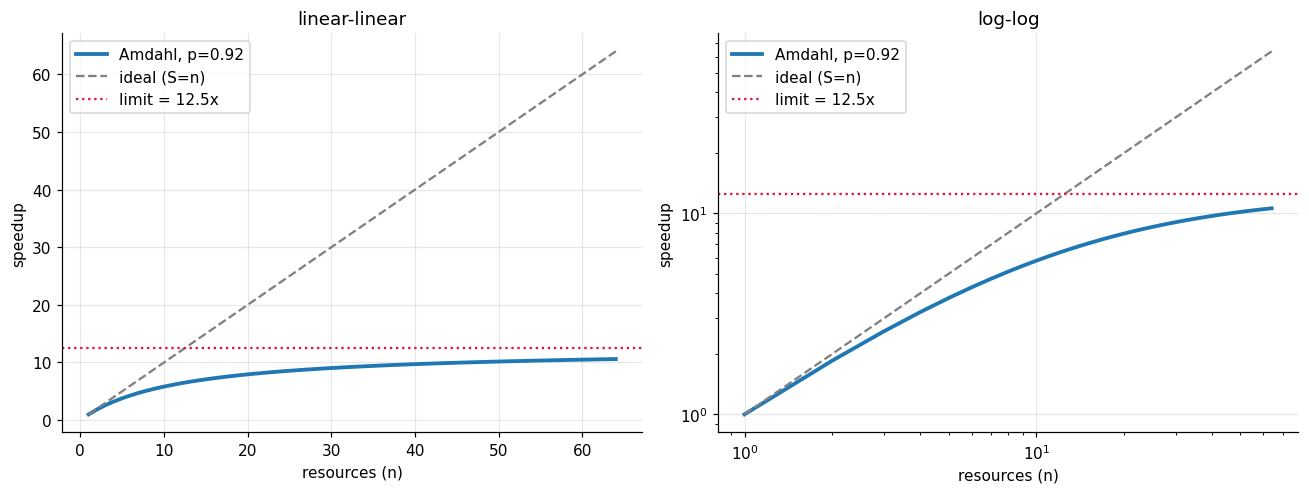

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

for ax, scale in ((ax1, "linear"), (ax2, "log")):
    ax.plot(n, amdahl(n, p), lw=2.5, label=f"Amdahl, p={p}")
    ax.plot(n, n, lw=1.5, ls="--", color="gray", label="ideal (S=n)")
    ax.axhline(1/(1-p), lw=1.5, color="crimson", ls=":", label=f"limit = {1/(1-p):.1f}x")
    ax.set_xlabel("resources (n)"); ax.set_ylabel("speedup")
    ax.set_xscale(scale); ax.set_yscale(scale)
    ax.set_title(f"{scale}-{scale}")
    ax.legend()
plt.tight_layout(); plt.show()

### How the curve depends on $p$

The whole point of Amdahl's law is that this dependence is brutal. A code that is 90% parallel
is not "90% of the way there" — it is capped at 10x no matter how large the machine.

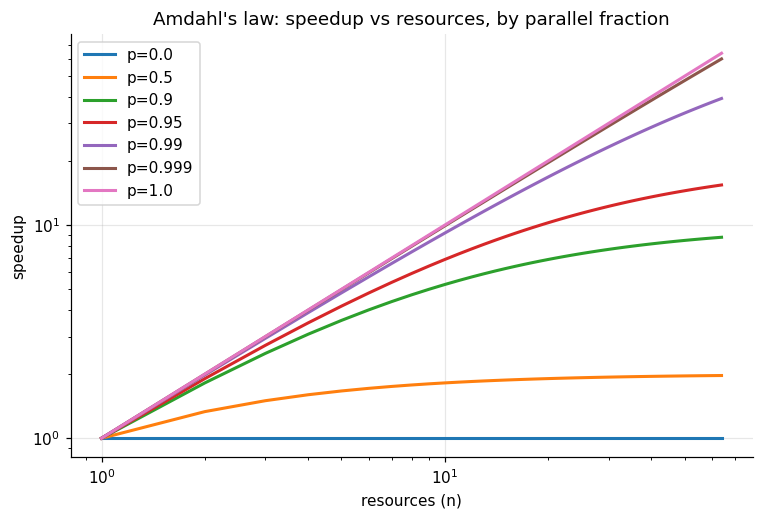

,p=0.0,p=0.5,p=0.9,p=0.95,p=0.99,p=0.999,p=1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.3,1.8,1.9,2.0,2.0,2.0
4,1.0,1.6,3.1,3.5,3.9,4.0,4.0
8,1.0,1.8,4.7,5.9,7.5,7.9,8.0
16,1.0,1.9,6.4,9.1,13.9,15.8,16.0
32,1.0,1.9,7.8,12.5,24.4,31.0,32.0
64,1.0,2.0,8.8,15.4,39.3,60.2,64.0


In [3]:
# Vectorised with broadcasting: p varies along the columns, n along the rows.
ps = np.array([0.0, 0.5, 0.9, 0.95, 0.99, 0.999, 1.0])
speedups = 1.0 / ((1.0 - ps)[None, :] + ps[None, :] / n[:, None])
df = pd.DataFrame(speedups, index=n, columns=[f"p={v}" for v in ps])

ax = df.plot(logx=True, logy=True, lw=2)
ax.set_xlabel("resources (n)"); ax.set_ylabel("speedup")
ax.set_title("Amdahl's law: speedup vs resources, by parallel fraction")
plt.show()

df.loc[[1, 2, 4, 8, 16, 32, 64]].round(1)

### Parallel efficiency

Speedup alone flatters large machines: 8x on 64 cores is a *bad* result but a big number.
**Efficiency** normalises it.

$$E(n) = \frac{S(n)}{n}$$

$E = 1$ is perfect scaling. Efficiency is what you should quote when you are paying for the
cores, because $1/E$ is the factor by which you are overpaying.

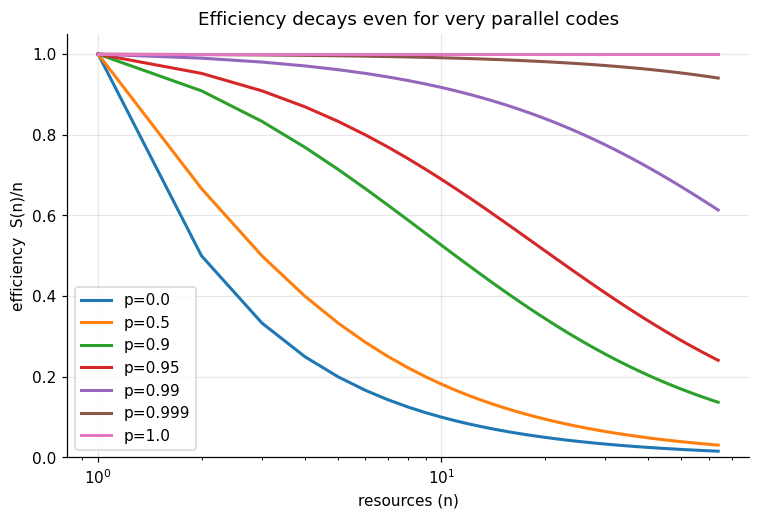

,p=0.0,p=0.5,p=0.9,p=0.95,p=0.99,p=0.999,p=1.0
1,1.000,1.000,1.000,1.000,1.000,1.000,1.0
4,0.250,0.400,0.769,0.870,0.971,0.997,1.0
16,0.062,0.118,0.400,0.571,0.870,0.985,1.0
64,0.016,0.031,0.137,0.241,0.613,0.941,1.0


In [4]:
eff = df.div(df.index, axis=0)
ax = eff.plot(logx=True, lw=2)
ax.set_xlabel("resources (n)"); ax.set_ylabel("efficiency  S(n)/n")
ax.set_ylim(0, 1.05); ax.set_title("Efficiency decays even for very parallel codes")
plt.show()

eff.loc[[1, 4, 16, 64]].round(3)

### Running the law backwards

*Suppose you want a speedup of 80 on 100 processors. How parallel must the code be?*

$$80 = \frac{1}{(1-p) + p/100} \;\;\Longrightarrow\;\; p = \frac{1 - 1/80}{1 - 1/100}$$

In [5]:
S_target, n_target = 80, 100
p_req = (1 - 1/S_target) / (1 - 1/n_target)
print(f"required parallel fraction : {p_req:.6f}")
print(f"allowed serial fraction    : {1 - p_req:.6f}  ({100*(1-p_req):.3f}% of the runtime)")

required parallel fraction : 0.997475
allowed serial fraction    : 0.002525  (0.253% of the runtime)


About a quarter of one percent may remain serial. That is the whole lesson of Amdahl's law in
one number.

### What counts as "serial"?

"Serial" is shorthand for *the part that does not benefit*. Sometimes that is literal:

* code running in one thread before the parallel region opens
* reading the input file
* the final reduction, if it is done by one thread

Often it is not literal at all:

* one process working while the others wait at a barrier — idle resources are unimproved time
* work the parallel version has to do that the serial one did not (partitioning, communication,
  reductions, redundant computation)
* time lost because the parallel version's memory access pattern is worse

The last two categories are the reason the model gets into trouble: they are not a fixed
fraction of the work. They **grow with $n$**, and Amdahl's law has nowhere to put them.

## 2. Inferring $p$ from measurements — the Karp–Flatt metric

Given a measured speedup $S$ on $n$ processors, invert the law:

$$e = \frac{\dfrac{1}{S} - \dfrac{1}{n}}{1 - \dfrac{1}{n}}, \qquad p = 1 - e$$

$e$ is the **experimentally determined serial fraction**. Computing it for one $n$ is not very
useful. Computing it *across* $n$ is a diagnostic, and this is the part usually left out:

* $e$ **roughly constant** as $n$ grows → the model fits. You really are limited by a fixed
  serial fraction, and $1/e$ is your ceiling.
* $e$ **rising** with $n$ → you are not limited by serial work but by something that grows:
  communication, synchronisation, load imbalance. Adding cores will disappoint faster than
  Amdahl predicts.
* $e$ **falling** with $n$ → the extra resources brought something with them, usually cache.

A single averaged number throws away exactly the information that distinguishes these cases.

In [6]:
def karp_flatt(procs, speedup):
    procs, speedup = np.asarray(procs, float), np.asarray(speedup, float)
    return (1/speedup - 1/procs) / (1 - 1/procs)

procs   = np.array([2, 4, 8, 16, 32])
speedup = np.array([1.85, 3.30, 5.34, 7.40, 9.40])
e = karp_flatt(procs, speedup)

pd.DataFrame({"processors": procs, "speedup": speedup,
              "serial fraction e": e.round(4), "implied p": (1 - e).round(4)})

,processors,speedup,serial fraction e,implied p
0,2,1.85,0.0811,0.9189
1,4,3.30,0.0707,0.9293
2,8,5.34,0.0712,0.9288
3,16,7.40,0.0775,0.9225
4,32,9.40,0.0776,0.9224


Here $e$ stays between 0.071 and 0.081 with no strong trend — near enough to constant that
Amdahl's law is a fair description of this code, with $p \approx 0.92$ and a ceiling of

$$S_{\max} = \lim_{n\to\infty} \frac{1}{(1-p) + p/n} = \frac{1}{1-p}$$

(The mild rise from $n=8$ onward — 0.071 to 0.078 — is a hint of overhead beginning to appear.
On five points it is not much to go on, which is itself worth noticing: this diagnostic needs a
*range* of $n$, and the more points the better.)

Note this is a *limit*, not an evaluation at $n=\infty$; writing $p/\infty$ is an abuse of
notation that hides the fact that you are taking a limit over a sequence of finite machines.

estimated p    : 0.9244
speedup ceiling: 13.2x


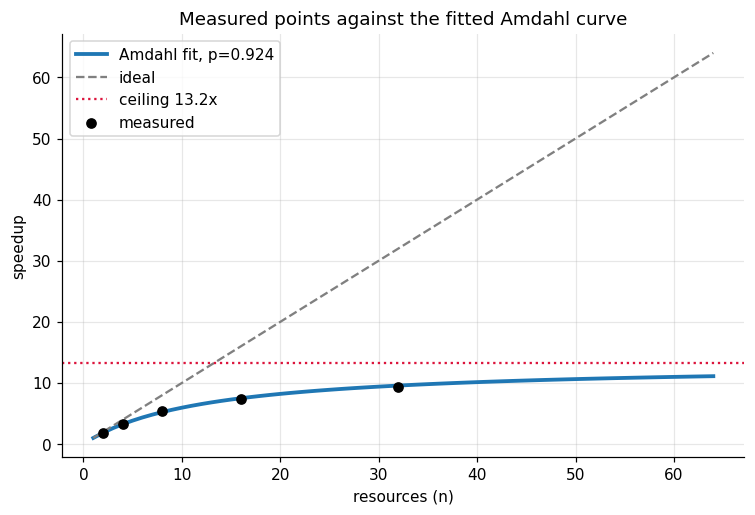

In [7]:
p_hat = 1 - e.mean()
print(f"estimated p    : {p_hat:.4f}")
print(f"speedup ceiling: {1/(1-p_hat):.1f}x")

plt.plot(n, amdahl(n, p_hat), lw=2.5, label=f"Amdahl fit, p={p_hat:.3f}")
plt.plot(n, n, lw=1.5, ls="--", color="gray", label="ideal")
plt.axhline(1/(1-p_hat), lw=1.5, ls=":", color="crimson", label=f"ceiling {1/(1-p_hat):.1f}x")
plt.scatter(procs, speedup, zorder=5, color="k", label="measured")
plt.xlabel("resources (n)"); plt.ylabel("speedup"); plt.legend()
plt.title("Measured points against the fitted Amdahl curve")
plt.show()

## 3. A real measurement, on resources the model recognises

Everything above is arithmetic. This section is a fixed-size problem measured on a real machine.

**The program** (`scaling_bench.c`) has exactly the two phases Amdahl's law describes:

* a **serial phase** — a linear recurrence `s = a*s + b`. Each step depends on the previous one,
  so it cannot be parallelised. Its length sets $1-p$.
* a **parallel phase** — a compute-bound map over a fixed 8 MB array, `#pragma omp for`. Fixed
  size: this is strong scaling, so the array never grows.

Three serial lengths give $p \approx 0.95$, $0.90$ and $0.75$.

**The machine** is an AMD Ryzen AI 9 HX 370, and it is *not* a uniform 12-core part. Cores 0–3
are Zen 5 with a high clock ceiling and share a 16 MB L3 (the CCX0 complex); cores 4–11 are
Zen 5c, clocked lower, sharing an 8 MB L3 (CCX1). Amdahl's law has no way to express any of that:
its $n$ is a count of *identical* resources.

So we start where the model has a fair chance — the eight Zen 5c cores of CCX1, which are
identical to each other and share one cache domain. §4 puts the same program on a mixed set.

In [8]:
HERE = Path.cwd()

def load_runs(fname):
    """Median over repetitions, plus speedup and efficiency per configuration."""
    raw = pd.read_csv(HERE / fname)
    med = (raw.groupby(["serial_steps", "threads"])[["serial_ms", "parallel_ms", "total_ms"]]
              .median().reset_index())
    one = med[med.threads == 1].set_index("serial_steps")
    p_by = (one.parallel_ms / (one.serial_ms + one.parallel_ms))   # measured, not assumed
    out = []
    for steps, g in med.groupby("serial_steps"):
        t1 = float(g[g.threads == 1].total_ms.iloc[0])
        out.append(g.assign(speedup=t1/g.total_ms,
                            efficiency=(t1/g.total_ms)/g.threads,
                            p=float(p_by[steps])))
    return pd.concat(out, ignore_index=True), p_by

ccx1, p_ccx1 = load_runs("ccx1.csv")     # 8 identical Zen 5c cores, one L3 domain

print("measured parallel fraction p:")
print(p_ccx1.round(4).to_string())
ccx1.pivot(index="threads", columns="serial_steps", values="speedup").round(2)

measured parallel fraction p:
serial_steps
322000     0.9512
680000     0.9016
2040000    0.7495


serial_steps,322000,680000,2040000
threads,,,
1,1.00,1.00,1.00
2,1.62,1.56,1.43
3,2.33,2.16,1.74
4,2.90,2.60,2.00
5,3.50,3.01,2.15
6,3.99,3.12,2.33
7,4.17,3.47,2.44
8,4.73,3.90,2.51


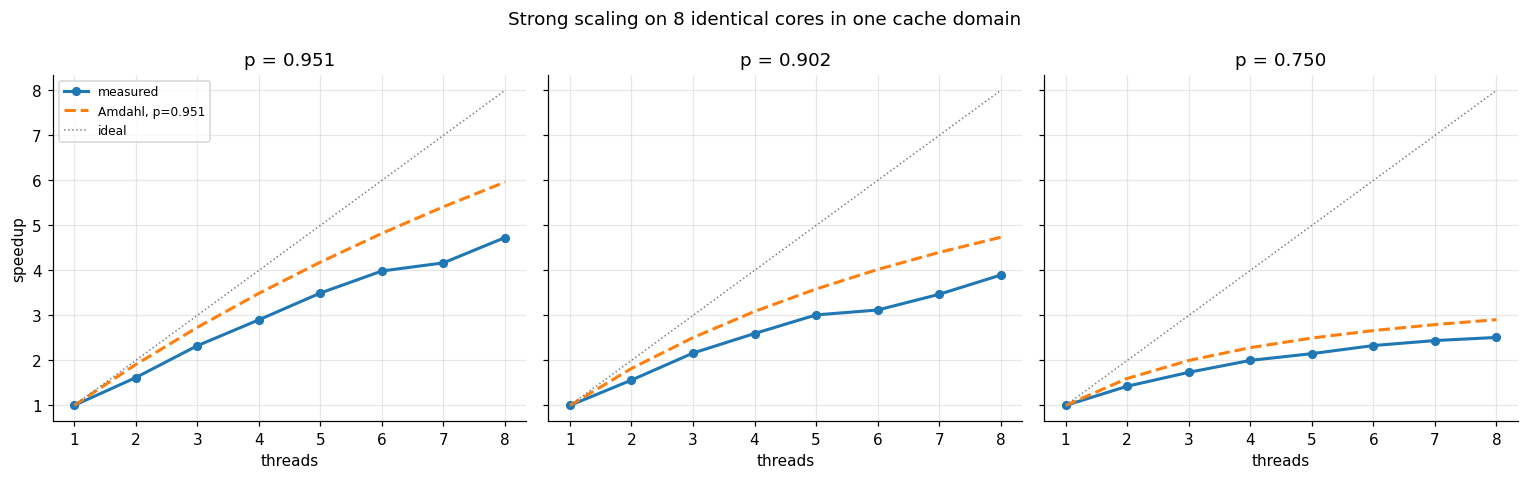

serial_steps,322000,680000,2040000
threads,,,
1,1.00,1.00,1.00
2,0.85,0.86,0.89
3,0.85,0.86,0.87
4,0.83,0.84,0.88
5,0.84,0.84,0.86
6,0.83,0.78,0.87
7,0.77,0.79,0.87
8,0.79,0.82,0.86


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
for ax, (steps, g) in zip(axes, ccx1.groupby("serial_steps")):
    pv = float(g.p.iloc[0])
    ax.plot(g.threads, g.speedup, "o-", lw=2, ms=5, label="measured")
    ax.plot(g.threads, amdahl(g.threads, pv), lw=2, ls="--", label=f"Amdahl, p={pv:.3f}")
    ax.plot(g.threads, g.threads, lw=1, ls=":", color="gray", label="ideal")
    ax.set_xlabel("threads"); ax.set_title(f"p = {pv:.3f}")
axes[0].set_ylabel("speedup"); axes[0].legend(fontsize=8)
plt.suptitle("Strong scaling on 8 identical cores in one cache domain")
plt.tight_layout(); plt.show()

# How much of the predicted speedup did we actually get?
ratio = ccx1.assign(frac=lambda d: d.speedup / amdahl(d.threads, d.p))
ratio.pivot(index="threads", columns="serial_steps", values="frac").round(2)

### The model works here

Three things to notice, and they are all *positive* results:

* the curves are **monotonic** — every thread added helps
* measured speedup is a **near-constant fraction of the prediction**, around 0.84 at $p=0.95$ and
  0.86 at $p=0.75$, with no drift as $n$ grows
* the curves bend away from ideal in exactly the way Amdahl says they should, and the more serial
  the code, the earlier they bend

A constant ratio is the signature of a **fixed** cost that the model does not include — here, the
per-region cost of waking threads and joining them at the barrier. It is charged once per
parallel region regardless of $n$, so it shows up as a constant tax rather than a growing one.

Karp–Flatt says the same thing more precisely.

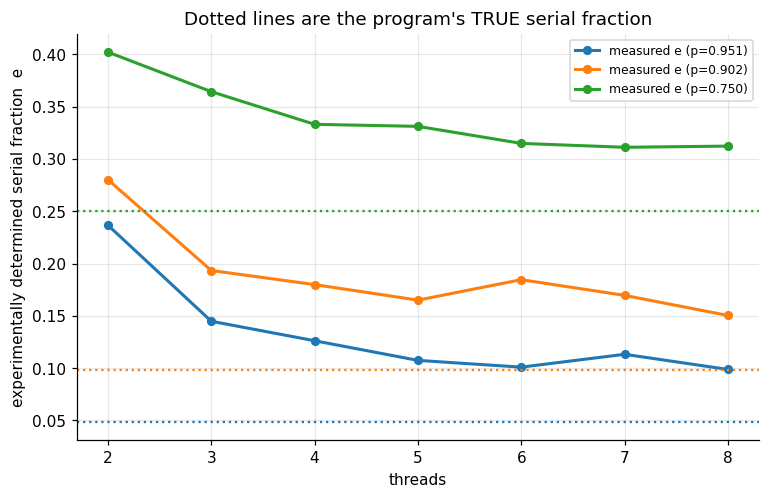

serial_steps,322000,680000,2040000
threads,,,
2,0.237,0.280,0.402
3,0.145,0.193,0.364
4,0.126,0.180,0.333
5,0.107,0.165,0.331
6,0.101,0.185,0.315
7,0.113,0.170,0.311
8,0.099,0.150,0.312


In [10]:
def kf_table(df):
    d = df[df.threads > 1].copy()
    d["e"] = karp_flatt(d.threads, d.speedup)
    return d

fig, ax = plt.subplots(figsize=(8, 4.8))
for steps, g in kf_table(ccx1).groupby("serial_steps"):
    pv = float(g.p.iloc[0])
    ax.plot(g.threads, g.e, "o-", ms=5, lw=2, label=f"measured e (p={pv:.3f})")
    ax.axhline(1 - pv, ls=":", lw=1.5, color=ax.lines[-1].get_color())
ax.set_xlabel("threads"); ax.set_ylabel("experimentally determined serial fraction  e")
ax.set_title("Dotted lines are the program's TRUE serial fraction")
ax.legend(fontsize=8); plt.show()

kf_table(ccx1).pivot(index="threads", columns="serial_steps", values="e").round(3)

$e$ starts high at $n=2$, falls, and then **flattens** — it does not trend upward. That is the
"Amdahl's law describes this code" verdict.

Two details worth reading properly:

* the inflated value at $n=2$ is the fixed per-region cost divided by a very small $n$; with few
  processors any constant overhead looks like a large serial fraction
* the level it settles at (~0.10 for the $p=0.95$ case) is about **twice** the program's true
  serial fraction (0.049). The extra is real, but it is *overhead*, not serial work — and because
  it is constant, the model still predicts the shape correctly

If every scaling study looked like this, Amdahl's law would be all you needed.

## 4. The same program, on resources the model does not recognise

Nothing about the code changes. The array is the same size, the serial phase is the same length,
$p$ is the same. The only change is *which cpus the threads are pinned to*: `0,1,2,…` instead of
`4,5,…,11`, so the run starts on the four fast Zen 5 cores of CCX0 and spills into CCX1 from the
fifth thread onward. It also continues past 12 threads, where the "extra resources" are SMT
siblings rather than cores.

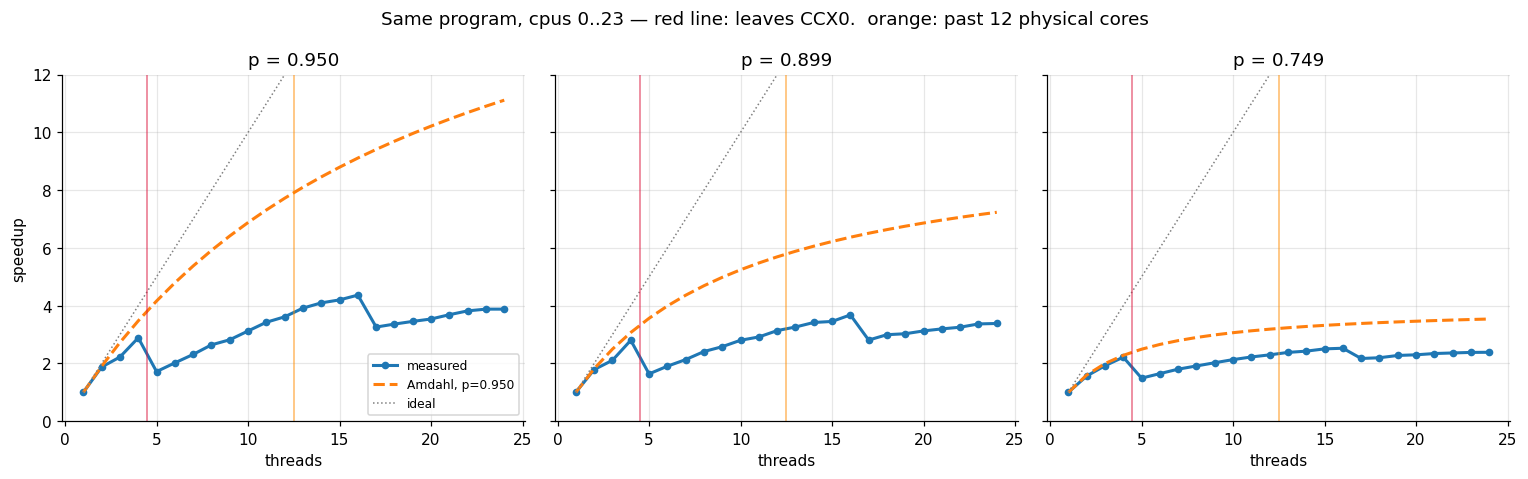

serial_steps,322000,680000,2040000
threads,,,
1,1.00,1.00,1.00
2,1.88,1.79,1.56
4,2.89,2.80,2.22
5,1.72,1.64,1.49
6,2.02,1.90,1.65
8,2.64,2.41,1.91
12,3.61,3.14,2.30
16,4.37,3.68,2.53
24,3.88,3.38,2.39


In [11]:
scal, p_measured = load_runs("scaling.csv")    # cpus 0,1,2,... 1 to 24 threads

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
for ax, (steps, g) in zip(axes, scal.groupby("serial_steps")):
    pv = float(g.p.iloc[0])
    ax.plot(g.threads, g.speedup, "o-", lw=2, ms=4, label="measured")
    ax.plot(g.threads, amdahl(g.threads, pv), lw=2, ls="--", label=f"Amdahl, p={pv:.3f}")
    ax.plot(g.threads, g.threads, lw=1, ls=":", color="gray", label="ideal")
    ax.axvline(4.5, color="crimson", lw=1, alpha=.6)
    ax.axvline(12.5, color="darkorange", lw=1, alpha=.6)
    ax.set_xlabel("threads"); ax.set_title(f"p = {pv:.3f}")
axes[0].set_ylabel("speedup"); axes[0].set_ylim(0, 12); axes[0].legend(fontsize=8)
plt.suptitle("Same program, cpus 0..23 — red line: leaves CCX0.  orange: past 12 physical cores")
plt.tight_layout(); plt.show()

scal[scal.threads.isin([1,2,4,5,6,8,12,16,24])].pivot(
    index="threads", columns="serial_steps", values="speedup").round(2)

### Everything that was true in §3 is now false

* the curve is **not monotonic** — speedup *falls* from 4 threads to 5. Amdahl's $S(n)$ is
  strictly increasing in $n$; it has no mechanism for "adding a resource made it slower"
* the ratio to the prediction is **not constant** — the gap widens with $n$
* past 16 threads it declines outright

Put the two Karp–Flatt traces side by side and the contrast is the whole diagnosis.

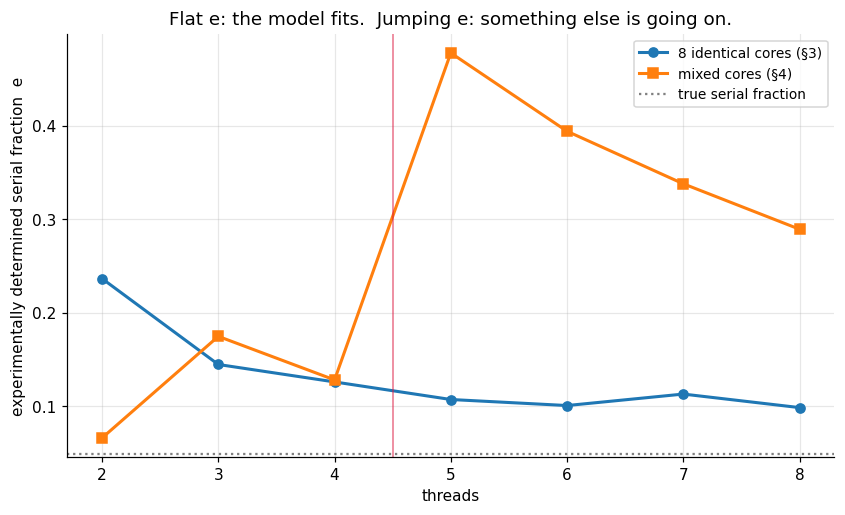

homogeneous: e goes 0.237 -> 0.099  (settles)
mixed      : e goes 0.066 -> 0.289  (7.2x range, discontinuity at n=5)


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
h = kf_table(ccx1); h = h[h.serial_steps == 322000]
m = kf_table(scal); m = m[(m.serial_steps == 322000) & (m.threads <= 8)]
ax.plot(h.threads, h.e, "o-", lw=2, ms=6, label="8 identical cores (§3)")
ax.plot(m.threads, m.e, "s-", lw=2, ms=6, label="mixed cores (§4)")
ax.axhline(1 - float(p_ccx1.loc[322000]), ls=":", color="gray", lw=1.5,
           label="true serial fraction")
ax.axvline(4.5, color="crimson", lw=1, alpha=.6)
ax.set_xlabel("threads"); ax.set_ylabel("experimentally determined serial fraction  e")
ax.set_title("Flat e: the model fits.  Jumping e: something else is going on.")
ax.legend(fontsize=9); plt.show()

print(f"homogeneous: e goes {h.e.iloc[0]:.3f} -> {h.e.iloc[-1]:.3f}  (settles)")
print(f"mixed      : e goes {m.e.iloc[0]:.3f} -> {m.e.iloc[-1]:.3f}  "
      f"({m.e.max()/m.e.min():.1f}x range, discontinuity at n=5)")

## 5. Finding the cause

Two hypotheses fit the dip at $n=5$ in §4 equally well, and they are confounded because the two
boundaries coincide:

* **core speed** — thread 5 lands on a Zen 5c core with a lower clock ceiling, and
  `schedule(static)` gives it an equal share of the work, so it becomes the critical path
* **memory locality** — thread 5 lands in the *other* L3 domain, and has to reach across the
  Infinity Fabric for data that lives in CCX0

Guessing between them is not allowed. Three experiments separate them.

**Experiment 1 — are the cores actually different speeds?** Run the identical kernel on one core
at a time, on each of the twelve.

In [13]:
pc = pd.read_csv(HERE / "percore.csv").groupby("cpu").median()
pc["domain"] = np.where(pc.index < 4, "CCX0 (Zen 5)", "CCX1 (Zen 5c)")
print(pc.round(3).to_string())
print()
print(f"parallel phase: {pc.parallel_ms.min():.2f} - {pc.parallel_ms.max():.2f} ms "
      f"({100*(pc.parallel_ms.max()/pc.parallel_ms.min()-1):.1f}% spread)")
print(f"serial phase  : {pc.serial_ms.min():.3f} - {pc.serial_ms.max():.3f} ms  "
      f"(a dependent FMA chain -- a direct clock proxy)")

     parallel_ms  serial_ms         domain
cpu                                       
0          7.276      0.381   CCX0 (Zen 5)
1          7.155      0.385   CCX0 (Zen 5)
2          7.315      0.384   CCX0 (Zen 5)
3          7.370      0.388   CCX0 (Zen 5)
4         11.474      0.589  CCX1 (Zen 5c)
5         11.207      0.588  CCX1 (Zen 5c)
6         10.982      0.590  CCX1 (Zen 5c)
7         11.139      0.587  CCX1 (Zen 5c)
8         11.008      0.590  CCX1 (Zen 5c)
9         10.971      0.588  CCX1 (Zen 5c)
10        11.213      0.587  CCX1 (Zen 5c)
11        11.032      0.591  CCX1 (Zen 5c)

parallel phase: 7.16 - 11.47 ms (60.4% spread)
serial phase  : 0.381 - 0.591 ms  (a dependent FMA chain -- a direct clock proxy)


**The cores are not the same speed.** The Zen 5c cores need about 11.1 ms where the Zen 5 cores
need about 7.2 ms — roughly 1.5x. The serial phase says the same thing more directly: it is a
dependent FMA chain, so its time is essentially a clock reading, and it goes from 0.385 ms on a
Zen 5 core to 0.589 ms on a Zen 5c core. That ratio, 1.53, is close to the 5.16 / 3.29 GHz ratio
of the two core types' clock ceilings.

So hypothesis 1 survives, and it has an obvious consequence: `schedule(static)` gives thread 5 an
equal share of the iterations but puts it on a core that needs 1.5x as long, and the parallel
phase cannot finish until its slowest thread does.

That is not proof, though — thread 5 also crossed into the other L3 domain at the same moment.

**Experiment 2 — move the boundary.** Pin the threads to different sets of cpus, so the crossing
happens at a different thread count, or never happens at all.

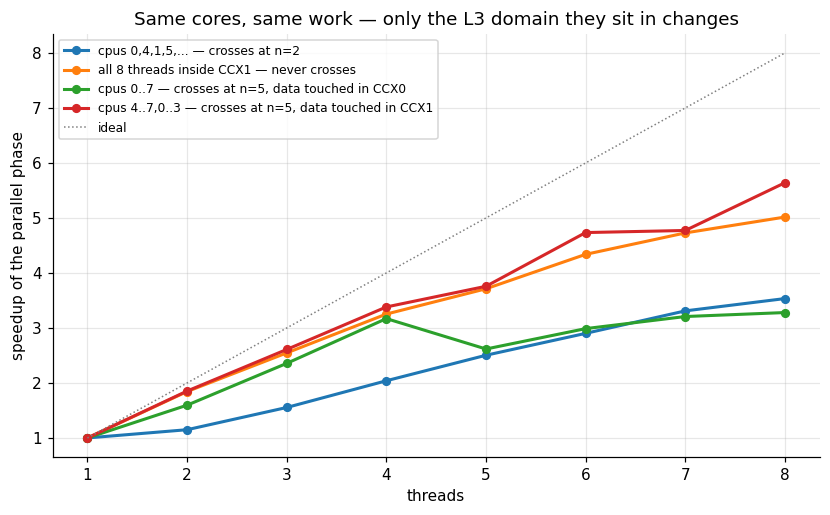

layout,alternating,ccx1_only,span_init_ccx0,span_init_ccx1
threads,,,,
1,1.00,1.00,1.00,1.00
2,1.15,1.84,1.60,1.85
3,1.55,2.55,2.36,2.61
4,2.04,3.25,3.17,3.38
5,2.50,3.71,2.62,3.76
6,2.90,4.34,2.99,4.73
7,3.31,4.73,3.21,4.77
8,3.53,5.02,3.28,5.64


In [14]:
zones = (pd.read_csv(HERE / "zones.csv")
           .groupby(["layout", "threads"])["parallel_ms"].median().reset_index())
zones["speedup"] = zones.groupby("layout")["parallel_ms"].transform(lambda s: s.iloc[0] / s)

labels = {"ccx1_only":      "all 8 threads inside CCX1 — never crosses",
          "span_init_ccx0": "cpus 0..7 — crosses at n=5, data touched in CCX0",
          "span_init_ccx1": "cpus 4..7,0..3 — crosses at n=5, data touched in CCX1",
          "alternating":    "cpus 0,4,1,5,... — crosses at n=2"}

fig, ax = plt.subplots(figsize=(9, 5))
for lab, g in zones.groupby("layout"):
    ax.plot(g.threads, g.speedup, "o-", lw=2, ms=5, label=labels[lab])
ax.plot([1, 8], [1, 8], ls=":", color="gray", lw=1, label="ideal")
ax.set_xlabel("threads"); ax.set_ylabel("speedup of the parallel phase")
ax.set_title("Same cores, same work — only the L3 domain they sit in changes")
ax.legend(fontsize=8); plt.show()

zones.pivot(index="threads", columns="layout", values="speedup").round(2)

Every curve is consistent with the core-speed story:

* **all eight threads inside CCX1** — every worker is an equally slow Zen 5c core, so an equal
  split is a *balanced* split, and scaling is smooth with no dip anywhere
* **cpus 0..7** — four fast cores, then slow ones from $n=5$: the dip is at $n=5$
* **cpus 4..7,0..3** — slow cores first, then fast ones. No dip: the baseline is already a slow
  core, and adding faster ones cannot make the critical path worse
* **cpus 0,4,1,5,…** — a slow core joins at $n=2$, and the penalty arrives at $n=2$

Note what has *not* been shown. Every one of those layouts changes the core mix and the L3 domain
together, because on this part CCX0 is exactly the four Zen 5 cores. The results are equally
consistent with a locality story: cross into the other domain and you pay the Infinity Fabric to
reach data that lives in CCX0's L3, which the companion `memory_hierarchy` measurements put at
~167 ns against ~105 ns for a DRAM miss.

**Experiment 3 — separate them.** Hold the workers fixed at the four Zen 5 cores of CCX0, so the
core mix cannot change, and vary *only* which domain first touches the array. Any difference is
locality; no difference means locality is not what is driving the dip.

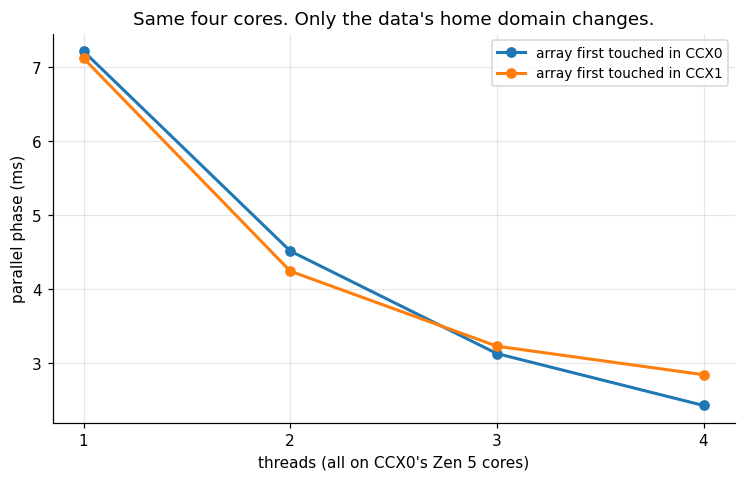

init_domain,CCX0,CCX1
threads,,
1,7.22,7.12
2,4.52,4.24
3,3.13,3.23
4,2.43,2.84


In [15]:
loc = (pd.read_csv(HERE / "locality.csv")
         .groupby(["init_domain", "threads"])["parallel_ms"].median().reset_index())

fig, ax = plt.subplots(figsize=(8, 4.6))
for lab, g in loc.groupby("init_domain"):
    ax.plot(g.threads, g.parallel_ms, "o-", lw=2, ms=6,
            label=f"array first touched in {lab}")
ax.set_xlabel("threads (all on CCX0's Zen 5 cores)")
ax.set_ylabel("parallel phase (ms)")
ax.set_title("Same four cores. Only the data's home domain changes.")
ax.set_xticks([1, 2, 3, 4]); ax.legend(fontsize=9); plt.show()

loc.pivot(index="threads", columns="init_domain", values="parallel_ms").round(2)

**No systematic difference.** The two curves track each other, and the largest gap — about 17%
at $n=4$ — *reverses sign* between repeat runs of this experiment, which is the signature of
noise rather than an effect. Compare that with the dip being explained, which is a stable 25%
loss that reproduces every time and always at the same thread count.

Locality is not the mechanism here, so the confound is broken and hypothesis 1 is what remains:

> The dip is **heterogeneous core speed meeting an equal-split schedule**. Adding a core that is
> 1.5x slower, and handing it an equal share of the work, extends the critical path by more than
> the extra core removes from it.

Why locality does *not* bite in this particular kernel is worth a sentence: every element is
read, modified and written by exactly one thread, so each line is acquired exclusively once and
never shared. There is no coherence traffic to pay the fabric for. A kernel where threads read
each other's data would behave completely differently — which is precisely why this had to be
measured rather than argued from the topology diagram.

### So what does the scheduling change actually do?

`schedule(static)` hands every thread an equal number of iterations, which is optimal only if
every thread retires them at the same rate. On four Zen 5 cores it is; the moment a Zen 5c core
joins, it is not. Handing work out on demand instead lets each core take as much as it can
finish.

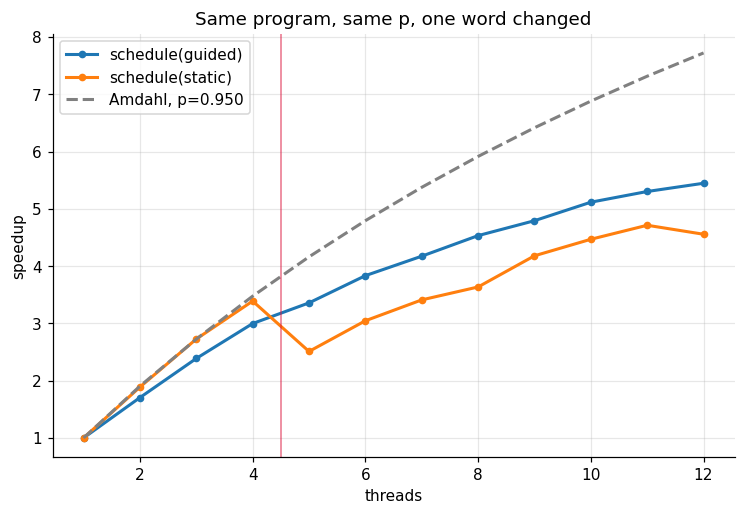

schedule,guided,static
threads,,
1,1.00,1.00
2,1.70,1.89
3,2.39,2.73
4,3.00,3.39
5,3.36,2.51
6,3.83,3.05
7,4.17,3.41
8,4.53,3.64
9,4.79,4.18


In [16]:
sch = pd.read_csv(HERE / "schedule.csv")
smed = sch.groupby(["schedule", "threads"])["total_ms"].median().reset_index()

out = []
for name, g in smed.groupby("schedule"):
    t1 = float(g[g.threads == 1].total_ms.iloc[0])
    out.append(g.assign(speedup=t1 / g.total_ms))
sched_df = pd.concat(out)

pv = float(p_measured.loc[322000])
fig, ax = plt.subplots()
for name, g in sched_df.groupby("schedule"):
    ax.plot(g.threads, g.speedup, "o-", lw=2, ms=4, label=f"schedule({name})")
ax.plot(g.threads, amdahl(g.threads, pv), ls="--", lw=2, color="gray",
        label=f"Amdahl, p={pv:.3f}")
ax.axvline(4.5, color="crimson", lw=1, alpha=.6)
ax.set_xlabel("threads"); ax.set_ylabel("speedup")
ax.set_title("Same program, same p, one word changed")
ax.legend()
plt.show()

sched_df.pivot(index="threads", columns="schedule", values="speedup").round(2)

### A model with somewhere to put the overhead

Amdahl's law assumes the parallel phase costs exactly $T_p/n$. The obvious repair is a term for
cost that grows with the number of workers:

$$T(n) = \underbrace{T_s}_{\text{serial}} \;+\; \underbrace{\frac{T_p}{n}}_{\text{divided work}} \;+\; \underbrace{c\,n}_{\text{overhead}}$$

Unlike Amdahl's, this model has a **minimum**: differentiating gives an optimal worker count
$n^\star = \sqrt{T_p/c}$, beyond which adding resources makes the program *slower*. That matches
the qualitative shape of many real measurements — and it is a much more useful thing to hand a
capacity planner than an asymptote.

So let us fit it to the data and read off $n^\star$.

In [17]:
g = scal[(scal.serial_steps == 322000)]
nn, T = g.threads.values.astype(float), g.total_ms.values

A = np.column_stack([np.ones_like(nn), 1/nn, nn])       # T = Ts + Tp/n + c*n
(Ts, Tp, c), *_ = np.linalg.lstsq(A, T, rcond=None)

print(f"fitted  Ts = {Ts:7.3f} ms   Tp = {Tp:7.3f} ms   c = {c:+.4f} ms/thread")
base = scal[(scal.serial_steps == 322000) & (scal.threads == 1)].iloc[0]
print(f"true    Ts = {base.serial_ms:7.3f} ms   Tp = {base.parallel_ms:7.3f} ms")
print()
print("c is NEGATIVE, so n* = sqrt(Tp/c) does not exist. The model does not fit.")
print(f"measured best thread count = {int(g.loc[g.total_ms.idxmin(), 'threads'])}")

fitted  Ts =   2.268 ms   Tp =   5.088 ms   c = -0.0251 ms/thread
true    Ts =   0.385 ms   Tp =   7.256 ms

c is NEGATIVE, so n* = sqrt(Tp/c) does not exist. The model does not fit.
measured best thread count = 16


**The fit fails, and the failure is informative.**

A negative $c$ says the least-squares fit wanted the overhead term to *reduce* runtime at high
$n$ — which is not overhead at all. The three-parameter model cannot describe this machine,
and it is worth being precise about why rather than quietly reporting the fitted numbers.

The model assumes overhead is **smooth in $n$**: a little more for each worker added. On this
part the losses are not smooth, they arrive as **steps**:

* nothing much up to $n=4$ — four identical fast cores
* a step down at $n=5$, when the first slow core joins and static scheduling makes it the
  critical path
* a second step past $n=12$, when "extra threads" stop being extra cores and become SMT siblings

A smooth curve fitted through a staircase gives parameters that describe neither. The honest
summary is that this machine needs a model with a term per *kind* of resource, not one term in
$n$ — or, more practically, that on a heterogeneous part you should measure rather than model.

The model is still worth knowing, because on a homogeneous cluster where the growing cost really
is communication it fits well. Here is the shape it predicts, with illustrative parameters:

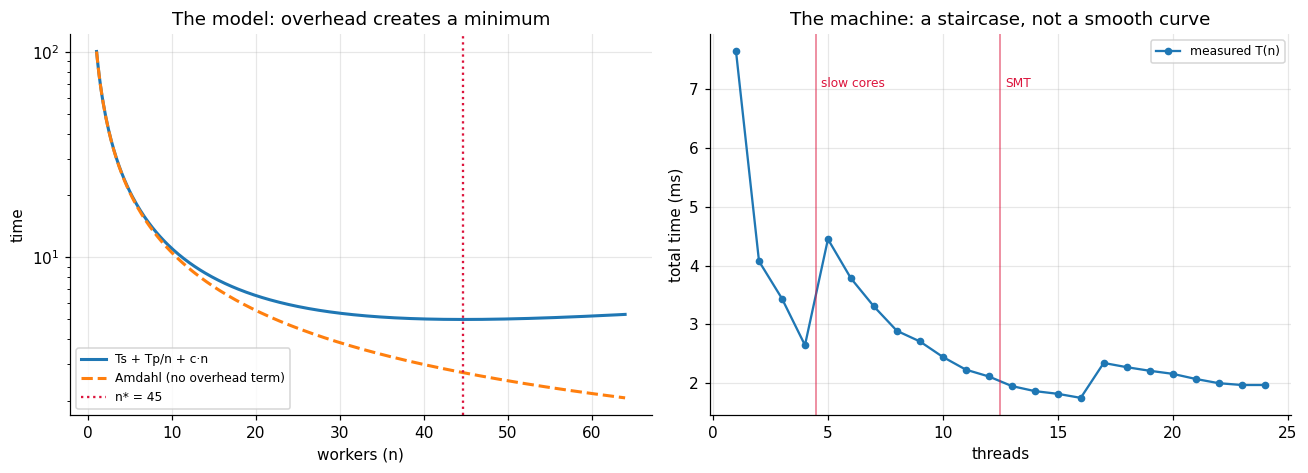

In [18]:
grid = np.linspace(1, 64, 400)
Ts_i, Tp_i, c_i = 0.5, 100.0, 0.05          # illustrative, not fitted
n_star = np.sqrt(Tp_i / c_i)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.4))
axa.plot(grid, Ts_i + Tp_i/grid + c_i*grid, lw=2, label="Ts + Tp/n + c·n")
axa.plot(grid, Ts_i + Tp_i/grid, lw=2, ls="--", label="Amdahl (no overhead term)")
axa.axvline(n_star, color="crimson", ls=":", lw=1.5, label=f"n* = {n_star:.0f}")
axa.set_xlabel("workers (n)"); axa.set_ylabel("time"); axa.set_yscale("log")
axa.set_title("The model: overhead creates a minimum"); axa.legend(fontsize=8)

axb.plot(nn, T, "o-", ms=4, lw=1.5, label="measured T(n)")
axb.axvline(4.5, color="crimson", lw=1, alpha=.6)
axb.axvline(12.5, color="crimson", lw=1, alpha=.6)
axb.text(4.7, T.max()*0.92, "slow cores", fontsize=8, color="crimson")
axb.text(12.7, T.max()*0.92, "SMT", fontsize=8, color="crimson")
axb.set_xlabel("threads"); axb.set_ylabel("total time (ms)")
axb.set_title("The machine: a staircase, not a smooth curve"); axb.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Measuring speedup without fooling yourself

Three defects were found and fixed while producing the data above. Each of them changed the
answer by more than the effect being studied.

**The runtime's idle policy.** By default libgomp's idle worker threads *spin* rather than sleep.
With threads pinned, spinners from a previous larger parallel region compete with the threads
doing the work. Left alone, this turned a 5x speedup at 16 threads into a 0.5x **slowdown** —
a property of the runtime, not the program. Fixed with `OMP_WAIT_POLICY=passive`.

**Cold clocks.** The first process to run after the machine has been idle executes about 1.4x
slower than the next one, across both phases. Measured as separate runs, whichever configuration
went first was penalised. Fixed by warming up for a fixed wall-clock time and measuring every
configuration inside one process.

**Ordering.** Sweeping $n$ upward puts $T(1)$ — the baseline that every speedup divides by —
in the least representative part of the run. Fixed by visiting all (configuration, thread count)
pairs in shuffled order and taking medians.

**`taskset` is not a fence.** The per-core numbers in §4 were first collected by running
`taskset -c $c ./scaling_bench`, and every core came back identical — which would have killed the
correct hypothesis. `taskset` sets a process's initial affinity mask, but a process may call
`sched_setaffinity` and *widen* it again, which is exactly what this program's own pinning does.
Every "per-core" run had migrated itself back to cpu 0. Pin from inside the program, and if you
must use an external tool, verify with `sched_getcpu()` that the threads are where you think.

A general rule: **any effect you can produce by changing the measurement procedure is not a
property of your program.** Before reporting a speedup, change something irrelevant — the order,
the repetition count, the wait policy — and check that the number does not move.

Also note what the timer must *not* let the compiler do. In `scaling_bench.c` the serial
recurrence is bracketed by `opaque()` and `sink()` calls. Without them, `gcc -O2` hoisted the
entire loop out from between the two clock readings, and the serial phase measured 0.000 ms.

## 7. What Amdahl's law assumes, and what it cannot see

| Assumption | Reality in the measurement above |
|---|---|
| Resources are identical | Measured 1.5x apart: 7.2 ms on a Zen 5 core, 11.1 ms on a Zen 5c core, for the same work |
| The parallel part speeds up by exactly $n$ | Adding the 5th thread made it *slower*; `guided` recovered much of the loss, without removing the cause |
| Parallelising adds no work | Scheduling, barriers and synchronisation all cost, and the cost grows with $n$ |
| The serial fraction is fixed | It is fixed *here* only because the benchmark was built that way |
| Speedup is monotonic in $n$ | Measured speedup fell from 4 threads to 5, and again past 16 |
| Speedup cannot exceed $n$ | **False in general.** $n$ cores bring $n$ private caches; a working set that thrashes on one core may fit across four. Superlinear speedup is real and is not a measurement error |

None of this makes the law useless. It makes it a **speed limit**, not a speedometer:

* it gives a ceiling before you write any parallel code — if the ceiling is 4x, an expensive
  parallelisation effort may not be worth it
* it tells you where to spend effort: reducing $1-p$ raises the ceiling, and nothing else does
* when the measured curve falls well below the Amdahl curve, that gap is a *bug report* about
  overhead, and it is usually fixable

## Activity

A serial profile shows 2% of the runtime outside the loop and 98% inside a loop you intend to
parallelise with `#pragma omp parallel for`.

1. Compute the exact Amdahl speedup at $n = 4$, $16$, and $64$.
2. Compute the parallel efficiency at each of those points. At which $n$ does efficiency first
   drop below 50%?
3. State the speedup ceiling, and the $n$ at which you reach 90% of it.
4. Draw the speedup chart with the three points, the ideal line, and the asymptote.
5. You then measure 3.6x on 4 threads and 9.0x on 16. Compute $e$ at both points. Is this code
   limited by its serial fraction, or by something else? What experiment would settle it?
6. The same measurement returns 4.4x on 4 threads. Amdahl's law says that is impossible for
   $p = 0.98$. Give a physical mechanism that produces it, and say what you would measure to
   confirm the mechanism rather than assume it.

## Parting thoughts

Amdahl's law is one equation with one parameter, and real performance is neither. It remains
worth knowing because of what it does *before* you spend any effort:

* **a back-of-the-envelope ceiling.** If 30% of your runtime is a serial file read, no amount of
  parallelism gets you past 3.3x. Find that out in a spreadsheet, not after a month of work.
* **a target for where to optimise.** Only shrinking the unimproved fraction raises the ceiling.
* **a reference curve.** The distance between your measurement and the Amdahl curve for your $p$
  is the part of the problem that is *your* code's fault rather than the algorithm's.

A workable process:

1. write the serial version, and make it a *good* serial version — it is the denominator of
   every speedup you will report
2. profile it to find where the time actually goes
3. compute the Amdahl ceiling for the part you could parallelise, and decide whether the ceiling
   justifies the work (parallel code is roughly 10x harder to write and debug)
4. parallelise, then measure against the ceiling — and when you fall short, use Karp–Flatt across
   $n$ to tell "inherently serial" apart from "overhead I can fix"

---

### Reproducing the measurements

```
gcc -O2 -fopenmp -o scaling_bench scaling_bench.c -lm

./scaling_bench --serial-steps 322000,680000,2040000 --max-threads 24 \
                --reps 15 --schedule static > scaling.csv

{ ./scaling_bench --serial-steps 322000 --max-threads 12 --reps 15 --schedule static
  ./scaling_bench --serial-steps 322000 --max-threads 12 --reps 15 --schedule guided | tail -n +2
} > schedule.csv
```

Measured on an AMD Ryzen AI 9 HX 370 (Zen 5 "Strix Point", 12C/24T), Ubuntu, gcc 13.3.0,
20 August 2026. The numbers in the prose are from this data; re-running on another machine will
change them, and the §3 discussion of heterogeneous cores applies only to parts built that way.